In [4]:
import numpy as np
from numpy.linalg import inv
A=np.array([1,2,3,0,-4,1,0,-3,1]).reshape(3,3)
b=np.array([2,2,1])
int(np.linalg.det(A))
x=inv(A).dot(b)
print(x)
Atrans=A.T
D=np.dot(A,Atrans)
if np.allclose(D,np.dot(A,Atrans),0):
    print("A is orthogonal")
else:
    print("A is not orthogonal")
Lambda, v = np.linalg.eig(A)
print(Lambda)

[10. -1. -2.]
A is orthogonal
[ 1.         -3.30277564  0.30277564]


In [41]:
import numpy as np
import math
def Ey(beta_deg):
    b = math.radians(beta_deg)
    return np.array([
        [math.cos(b), 0, -math.sin(b)],
        [0, 1, 0],
        [math.sin(b), 0, math.cos(b)]
    ])

def Ez(gamma_deg):
    g = math.radians(gamma_deg)
    return np.array([
        [math.cos(g), math.sin(g), 0],
        [-math.sin(g), math.cos(g), 0],
        [0, 0, 1]
    ])


result = Ez(180-123)@Ey(90-27.4)@Ez(192.25)
print(result)
if np.allclose(result.T,inv(result),0) and np.linalg.det(result)==1:
    print("matrix is chill")
else: ("watch out pookie")
Lambda, v = np.linalg.eig(result)
print(Lambda)

alpha = math.radians(192.25)   # R.A.
delta = math.radians(27.4)   # Dec

v = np.array([
    math.cos(delta) * math.cos(alpha),
    math.cos(delta) * math.sin(alpha),
    math.sin(delta)
])
print(v)
v2=result@v
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
matrix is chill
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[-0.86760081 -0.1883746   0.46019978]
[2.77555756e-17 5.55111512e-17 1.00000000e+00]


Polynomial coefficients (a0, a1, ..., aN-1):
[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


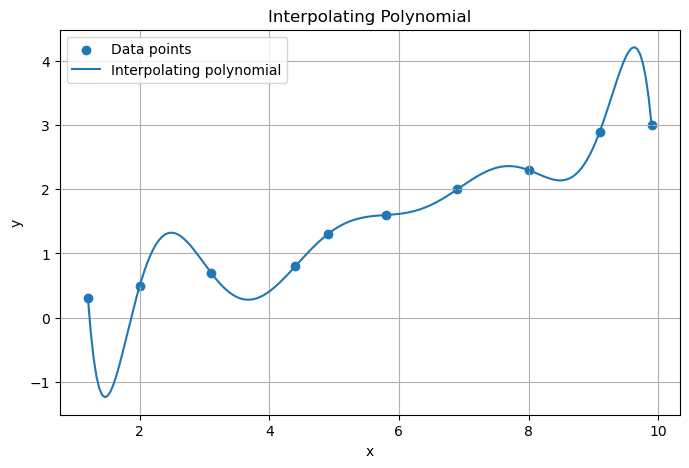

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


N = len(x)
A = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        A[i, j] = x[i] ** j   # increasing powers (a0 + a1*x + ...)

coeffs = np.linalg.solve(A, y)

print("Polynomial coefficients (a0, a1, ..., aN-1):")
print(coeffs)

# Generate smooth x values for plotting
x_smooth = np.linspace(min(x), max(x), 200)

# Evaluate polynomial using loops
y_smooth = np.zeros_like(x_smooth)
for i in range(N):
    y_smooth += coeffs[i] * (x_smooth ** i)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(x, y, label='Data points')
plt.plot(x_smooth, y_smooth, label='Interpolating polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolating Polynomial')
plt.legend()
plt.grid()
plt.show()

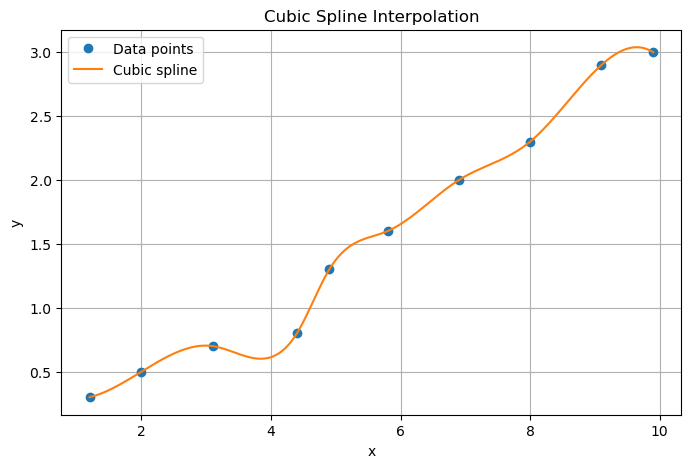

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


f_cubic = interp1d(x, y, kind='cubic')


x_new = np.linspace(min(x), max(x), 200)
y_new = f_cubic(x_new)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Data points')
plt.plot(x_new, y_new, '-', label='Cubic spline')
plt.legend()
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Cubic Spline Interpolation')
plt.show()

In [49]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


In [15]:
import numpy as np

data = np.array([
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9, 3.0, 80,
    11.34, 872.13, 1.2, 80,
    7.12, 432.2, 0.4, 70,
    9.82, 751, 0.3, 75,
    23.66, 1410, 2.3, 70,
    44, 2700, 4.0, 110,
    66.7, 5292, 5.3, 120,
    52.4, 2550, 5.2, 100,
    55, 5253, 6.1, 150,
    25.6, 2419, 3.2, 110,
    26.19, 2158, 2.8, 110
])

d = data[0::4]  # Distance (Mpc)
v = data[1::4]  # Velocity (km/s)
sig_d = data[2::4]  # Error in distance
sig_v = data[3::4]  # Error in velocity

from scipy.optimize import leastsq


def residuals(beta, d, v, sig_v):
    H0,v0=beta
    return (v - H0 * d + v0) / sig_v

beta_start = [70, 0]
result = leastsq(residuals, beta_start, args=(d, v, sig_v))
print(result)
from scipy.optimize import curve_fit



(array([ 64.13233646, -69.93800321]), 1)


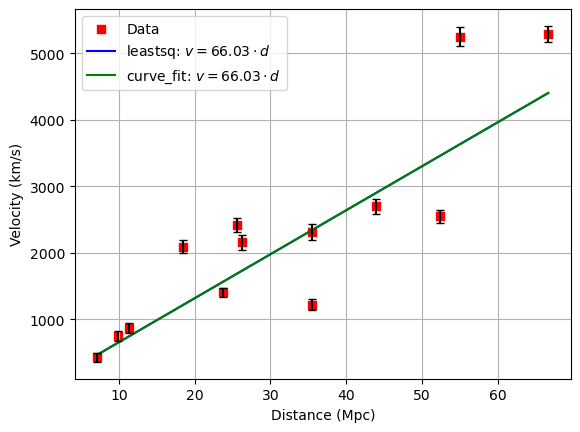

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

data = np.array([
    [18.49, 2094.75, 0.3, 100],
    [35.48, 2320.87, 2.2, 120],
    [35.48, 1224.9, 3.0, 80],
    [11.34, 872.13, 1.2, 80],
    [7.12, 432.2, 0.4, 70],
    [9.82, 751, 0.3, 75],
    [23.66, 1410, 2.3, 70],
    [44, 2700, 4.0, 110],
    [66.7, 5292, 5.3, 120],
    [52.4, 2550, 5.2, 100],
    [55, 5253, 6.1, 150],
    [25.6, 2419, 3.2, 110],
    [26.19, 2158, 2.8, 110]
])

d = data[:, 0]
v = data[:, 1]
sigv = data[:, 3]

def hubble_model(d, H0):
    return H0 * d

def residuals(H0, d, v, sigv):
    return (v - hubble_model(d, H0)) / sigv
H0_start = 70.0

result = leastsq(residuals, H0_start, args=(d, v, sigv), full_output=1)
H0_lsq = result[0][0]
popt, pcov = curve_fit(hubble_model, d, v, sigma=sigv, p0=H0_start)
H0_cf = popt[0]

# Plot
plt.scatter(d, v, marker='s', color='red', label='Data')
d_plot = np.linspace(min(d), max(d), 100)
plt.plot(d_plot, hubble_model(d_plot, H0_lsq), label=r'leastsq: $v = {:.2f} \cdot d$'.format(H0_lsq), color='blue')
plt.plot(d_plot, hubble_model(d_plot, H0_cf), label=r'curve_fit: $v = {:.2f} \cdot d$'.format(H0_cf), color='green')
plt.errorbar(d, v, yerr=sigv, fmt='none', color='black', capsize=3)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()